# Step 3 - Create TFIDFs for each group to rank terms

The 4 corpora used for TFIDF creation are:
- NMF Abstracts (2706)
- Non-NMF Abstracts (24,737)
- NMF Full Texts (311)
- Non-NMF Full Texts (3545)

## 3.1 - Abstracts NMF Corpus

In [1]:
import functions

In [2]:
functions.outputs.make_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\Abstracts_TM", "txt")

In [ ]:
#csv called corpus.csv saved to current working directory


In [3]:
import pandas as pd
import csv

df=pd.read_csv('corpus.csv', encoding = 'unicode_escape', encoding_errors = 'ignore', engine ='c')
df.head()

,name,text
0,10648442.txt,1. Brain. 2000 Feb;123 ( Pt 2):353-65. doi: 10...
1,10695575.txt,1. Brain Inj. 2000 Feb;14(2):197-203. doi: 10....
2,10695844.txt,1. Clin J Sport Med. 2000 Jan;10(1):9-14. doi:...
3,10715976.txt,1. Surgery. 2000 Mar;127(3):245-53. doi: 10.10...
4,10723184.txt,1. No To Hattatsu. 2000 Mar;32(2):110-5.\n\n[T...


In [4]:
df['processed_text'] = df['text'].apply(functions.processing.preprocess)
df.head()

,name,text,processed_text
0,10648442.txt,1. Brain. 2000 Feb;123 ( Pt 2):353-65. doi: 10...,"[brain, feb, brainelectrophysiological, eviden..."
1,10695575.txt,1. Brain Inj. 2000 Feb;14(2):197-203. doi: 10....,"[brain, inj, feb, neuropsychological, assessme..."
2,10695844.txt,1. Clin J Sport Med. 2000 Jan;10(1):9-14. doi:...,"[clin, sport, med, jan, concussions, canadian,..."
3,10715976.txt,1. Surgery. 2000 Mar;127(3):245-53. doi: 10.10...,"[surgery, mar, msyimprovement, information, co..."
4,10723184.txt,1. No To Hattatsu. 2000 Mar;32(2):110-5.\n\n[T...,"[hattatsu, martraumatic, brain, injury, childr..."


In [5]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x))
#add in a line to remove 0 wc texts
df = df[~(df.word_count == 0)]


df.head()

,name,text,processed_text,word_count
0,10648442.txt,1. Brain. 2000 Feb;123 ( Pt 2):353-65. doi: 10...,"[brain, feb, brainelectrophysiological, eviden...",158
1,10695575.txt,1. Brain Inj. 2000 Feb;14(2):197-203. doi: 10....,"[brain, inj, feb, neuropsychological, assessme...",118
2,10695844.txt,1. Clin J Sport Med. 2000 Jan;10(1):9-14. doi:...,"[clin, sport, med, jan, concussions, canadian,...",129
3,10715976.txt,1. Surgery. 2000 Mar;127(3):245-53. doi: 10.10...,"[surgery, mar, msyimprovement, information, co...",164
4,10723184.txt,1. No To Hattatsu. 2000 Mar;32(2):110-5.\n\n[T...,"[hattatsu, martraumatic, brain, injury, childr...",120


In [6]:
# Descriptive statistics for word count
df['word_count'].describe()
#95%CI Calculated: 

count    2702.000000
mean      163.358993
std        69.870610
min         8.000000
25%       120.000000
50%       159.000000
75%       200.750000
max       927.000000
Name: word_count, dtype: float64

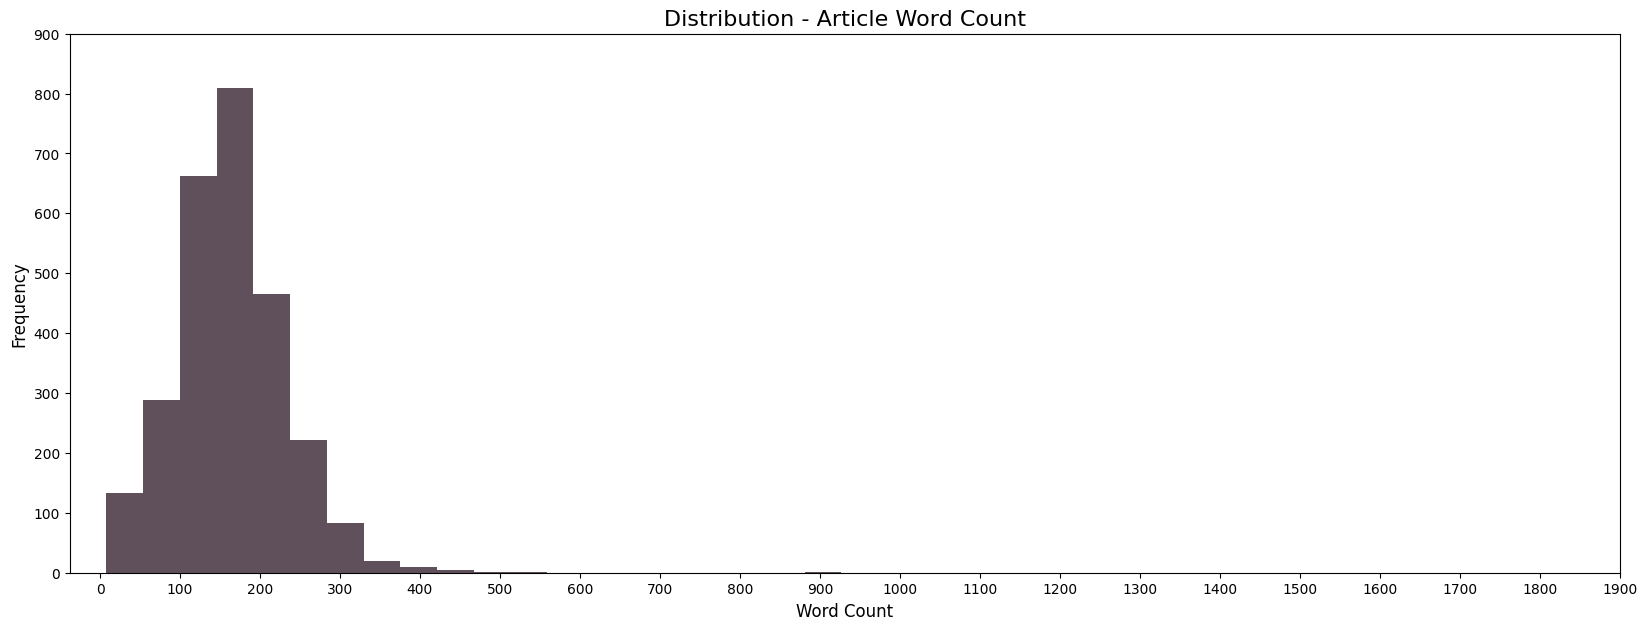

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Plot a hist of the word counts
fig = plt.figure(figsize=(20,7))

plt.hist(
    df['word_count'],
    bins=20,
    color='#60505C'
)

plt.title('Distribution - Article Word Count', fontsize=16)
plt.ylabel('Frequency', fontsize=12)
plt.xlabel('Word Count', fontsize=12)
plt.yticks(np.arange(0, 1000, 100))
plt.xticks(np.arange(0, 2000, 100))

file_name = 'hist'

plt.show()

In [8]:
from collections import Counter

# Get the top 20 most common words among all the articles
p_text = df['processed_text']

# Flatten the list of lists
p_text = [item for sublist in p_text for item in sublist]

# Top 20
top_20 = pd.DataFrame(
    Counter(p_text).most_common(20),
    columns=['word', 'frequency']
)

top_20

,word,frequency
0,patient,6584
1,brain,5175
2,consciousness,4463
3,university,4326
4,injury,3578
5,state,2966
6,study,2726
7,disorder,2576
8,index,2198
9,conscious,1711


In [9]:
# Get the number of unique words after processing
num_unique_words = len(set(p_text))
num_unique_words

40683

In [10]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from operator import itemgetter

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# create a dataframe with the text data
df['string_text'] = df["processed_text"].apply(lambda x: ' '.join(x))


df.head()

# create the TfidfVectorizer object
vectorizer = TfidfVectorizer()

# fit the vectorizer to the data and transform the data
tfidf_scores = vectorizer.fit_transform(df['string_text'])

# get the feature names
feature_names = vectorizer.get_feature_names_out()

# create a dataframe with the tf-idf scores
tfidf_df = pd.DataFrame(tfidf_scores.toarray(), columns=feature_names)

In [12]:
# calculate the mean tf-idf value for each word across the corpus
mean_tfidf = tfidf_df.mean()

# sort the mean tf-idf values in descending order
mean_tfidf = mean_tfidf.sort_values(ascending=False)

# view the top 10 most important words
print(mean_tfidf.head(10))

patient          0.043700
brain            0.032360
injury           0.028707
consciousness    0.027843
university       0.025315
state            0.023946
disorder         0.019670
study            0.017812
tbi              0.016918
conscious        0.016422
dtype: float64


In [13]:
dict_path = r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Dictionaries\aalbi2026.csv"
dictionary = []
dictionary = pd.read_csv(dict_path)["Replacement"].tolist()
dictionary

['precentral',
 'frontal_sup',
 'frontal_mid',
 'frontal_inf_oper',
 'frontal_inf_tri',
 'frontal_inf_orb',
 'rolandic_oper',
 'supp_motor_area',
 'olfactory',
 'frontal_sup_medial',
 'frontal_med_orb',
 'rectus',
 'ofcmed',
 'ofcant',
 'ofcpost',
 'ofclat',
 'insula',
 'cingulate_ant',
 'cingulate_mid',
 'cingulate_post',
 'hippocampus',
 'parahippocampal',
 'amygdala',
 'calcarine',
 'cuneus',
 'lingual',
 'occipital_sup',
 'occipital_mid',
 'occipital_inf',
 'fusiform',
 'postcentral',
 'parietal_sup',
 'parietal_inf',
 'supramarginal',
 'angular',
 'precuneus',
 'paracentral_lobule',
 'caudate',
 'putamen',
 'pallidum',
 'heschl',
 'temporal_sup',
 'temporal_pole_sup',
 'temporal_mid',
 'temporal_pole_mid',
 'temporal_inf',
 'cerebellum_crus',
 'cerebellum_aal',
 'vermis',
 'thalamus',
 'thal_av',
 'thal_lp',
 'thal_va',
 'thal_vl',
 'thal_vpl',
 'thal_il',
 'thal_re',
 'thal_mdm',
 'thal_mdl',
 'thal_lgn',
 'thal_mgn',
 'thal_pua',
 'thal_pum',
 'thal_pul',
 'thal_pui',
 'thal_nuc

In [14]:
# create a list
my_list = dictionary

# create a set of items to remove from the list
remove_set = set([w for w in dictionary if w not in tfidf_df.columns])

# convert the list to a set and use the difference() method to remove the items
my_list = list(set(my_list).difference(remove_set))

# view the resulting list
print(my_list)

['insula', 'cingulate_mid', 'thalamus', 'parahippocampal', 'temporal_inf', 'thal_vl', 'cingulate_ant', 'supp_motor_area', 'temporal_sup', 'paracentral_lobule', 'temporal_pole_sup', 'hippocampus', 'supramarginal', 'amygdala', 'calcarine', 'postcentral', 'cuneus', 'parietal_sup', 'frontal_mid', 'cerebellum_aal', 'olfactory', 'precentral', 'parietal_inf', 'lingual', 'pallidum', 'temporal_mid', 'occipital_mid', 'frontal_sup', 'rolandic_oper', 'precuneus', 'fusiform', 'cingulate_post', 'caudate']


In [15]:
# create a list of the words to find the mean tf-idf values for
words = my_list

# calculate the mean tf-idf value for each word in the list
mean2_tfidf = tfidf_df[words].mean()

# sort the mean tf-idf values in descending order
mean2_tfidf = mean2_tfidf.sort_values(ascending=False)

# view the top 10 most important words
print(mean2_tfidf.head(10))

thalamus          0.002799
olfactory         0.002468
precuneus         0.000963
cingulate_ant     0.000887
amygdala          0.000696
cingulate_post    0.000683
hippocampus       0.000638
cerebellum_aal    0.000536
insula            0.000498
temporal_sup      0.000419
dtype: float64


This is an analysis and TFIDF of the most common terms to appear in the Abstracts NMF Corpus

## 3.2 - Abstracts Non-NMF Corpus

In [16]:
import functions

In [17]:
functions.outputs.make_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\Abstracts_NON_TM", "txt")

In [ ]:
#csv called corpus.csv saved to current working directory


In [18]:
import pandas as pd
import csv

df=pd.read_csv('corpus.csv', encoding = 'unicode_escape', encoding_errors = 'ignore', engine ='c')
df.head()

,name,text
0,10601807.txt,1. Eur Neurol. 2000;43(1):39-46. doi: 10.1159/...
1,10613939.txt,1. Ann Emerg Med. 2000 Jan;35(1):43-6. doi: 10...
2,10618329.txt,1. Heart. 2000 Jan;83(1):22-3. doi: 10.1136/he...
3,10618330.txt,1. Heart. 2000 Jan;83(1):24-8. doi: 10.1136/he...
4,10624990.txt,1. Anesth Analg. 2000 Jan;90(1):116-8. doi: 10...


In [19]:
df['processed_text'] = df['text'].apply(functions.processing.preprocess)
df.head()

,name,text,processed_text
0,10601807.txt,1. Eur Neurol. 2000;43(1):39-46. doi: 10.1159/...,"[eur, neurol, simultaneous, assessment, brain,..."
1,10613939.txt,1. Ann Emerg Med. 2000 Jan;35(1):43-6. doi: 10...,"[ann, emerg, med, jan, sxhypoglycemia, abcs, s..."
2,10618329.txt,1. Heart. 2000 Jan;83(1):22-3. doi: 10.1136/he...,"[heart, jan, heartdiagnosis, carotid, sinus, h..."
3,10618330.txt,1. Heart. 2000 Jan;83(1):24-8. doi: 10.1136/he...,"[heart, jan, heartclinical, feature, adenosine..."
4,10624990.txt,1. Anesth Analg. 2000 Jan;90(1):116-8. doi: 10...,"[anesth, analg, jan, prolong, coma, quadripleg..."


In [20]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x))
#add in a line to remove 0 wc texts
df = df[~(df.word_count == 0)]


df.head()

,name,text,processed_text,word_count
0,10601807.txt,1. Eur Neurol. 2000;43(1):39-46. doi: 10.1159/...,"[eur, neurol, simultaneous, assessment, brain,...",133
1,10613939.txt,1. Ann Emerg Med. 2000 Jan;35(1):43-6. doi: 10...,"[ann, emerg, med, jan, sxhypoglycemia, abcs, s...",164
2,10618329.txt,1. Heart. 2000 Jan;83(1):22-3. doi: 10.1136/he...,"[heart, jan, heartdiagnosis, carotid, sinus, h...",170
3,10618330.txt,1. Heart. 2000 Jan;83(1):24-8. doi: 10.1136/he...,"[heart, jan, heartclinical, feature, adenosine...",203
4,10624990.txt,1. Anesth Analg. 2000 Jan;90(1):116-8. doi: 10...,"[anesth, analg, jan, prolong, coma, quadripleg...",30


In [21]:
# Descriptive statistics for word count
df['word_count'].describe()
#95%CI Calculated: 

count    23975.000000
mean       121.804213
std         89.266726
min          3.000000
25%         44.000000
50%        118.000000
75%        173.000000
max       2641.000000
Name: word_count, dtype: float64

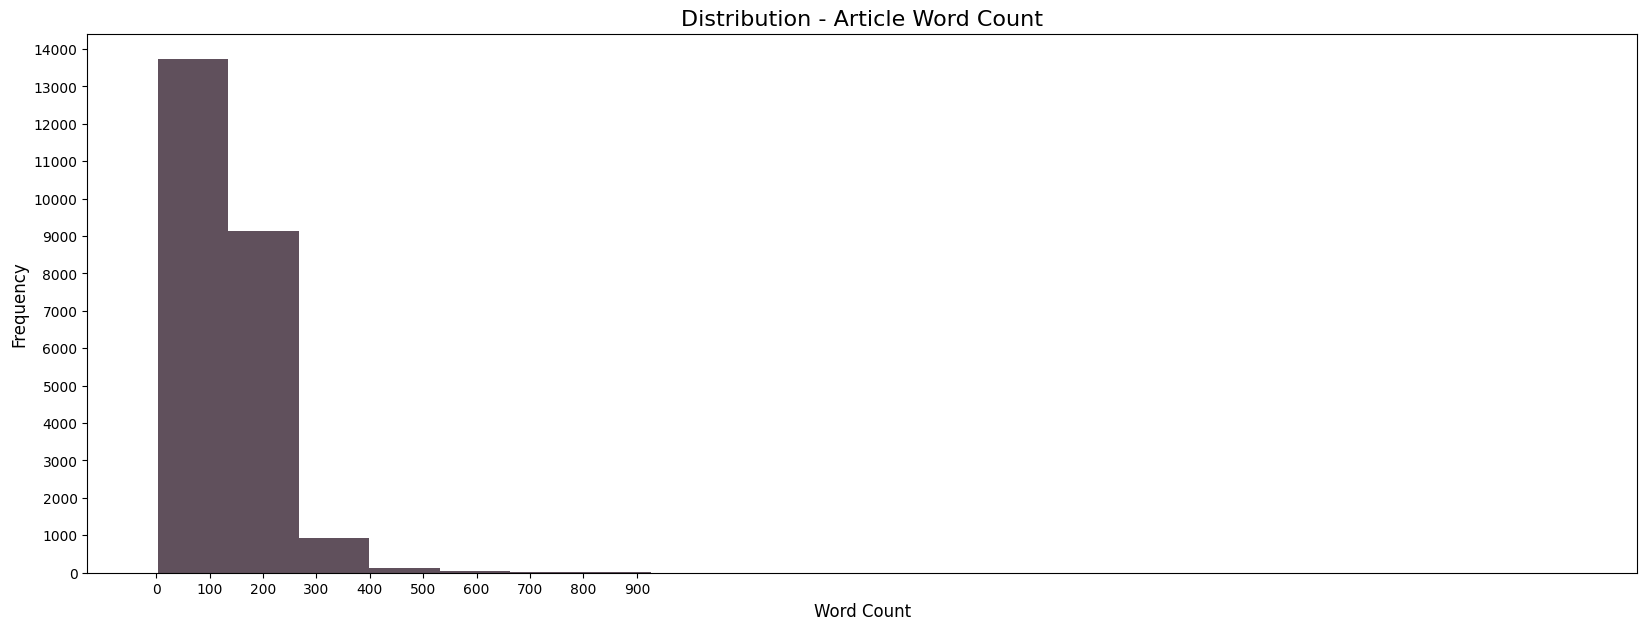

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Plot a hist of the word counts
fig = plt.figure(figsize=(20,7))

plt.hist(
    df['word_count'],
    bins=20,
    color='#60505C'
)

plt.title('Distribution - Article Word Count', fontsize=16)
plt.ylabel('Frequency', fontsize=12)
plt.xlabel('Word Count', fontsize=12)
plt.yticks(np.arange(0, 15000, 1000))
plt.xticks(np.arange(0, 1000, 100))

file_name = 'hist'

plt.show()

In [23]:
from collections import Counter

# Get the top 20 most common words among all the articles
p_text = df['processed_text']

# Flatten the list of lists
p_text = [item for sublist in p_text for item in sublist]

# Top 20
top_20 = pd.DataFrame(
    Counter(p_text).most_common(20),
    columns=['word', 'frequency']
)

top_20

,word,frequency
0,patient,47533
1,university,33521
2,hospital,23367
3,index,20639
4,medicine,18415
5,medline,17111
6,medical,16794
7,brain,15441
8,study,14954
9,syncope,14732


C:\Users\noahj\AppData\Local\Temp\ipykernel_3188\2553095217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
C:\Users\noahj\AppData\Local\Temp\ipykernel_3188\2553095217.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(


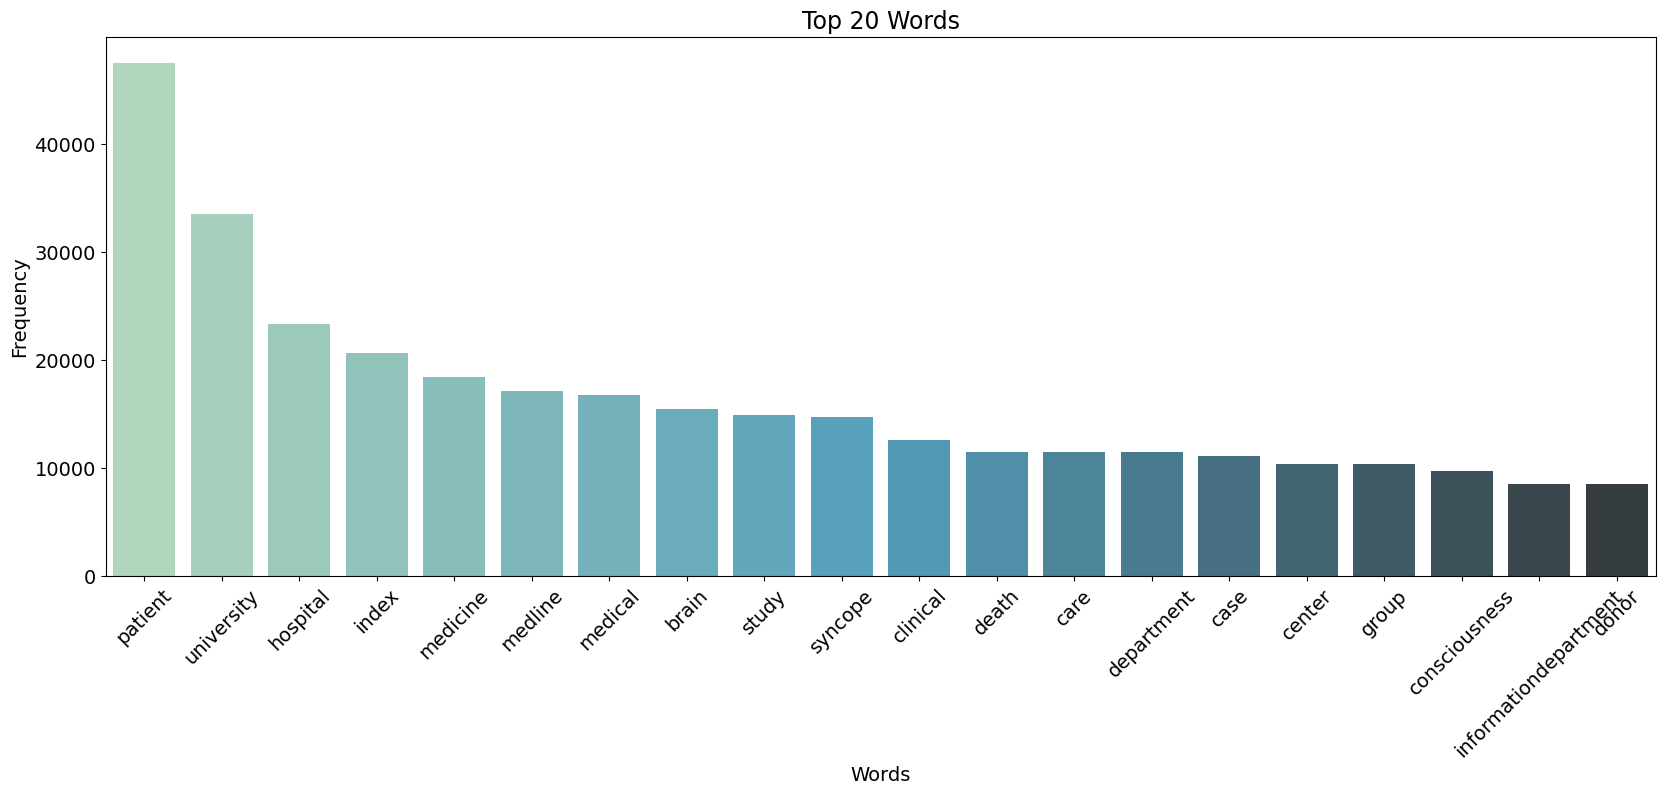

In [24]:
import seaborn as sns

# Plot a bar chart for the top 20 most frequently occurring words
fig = plt.figure(figsize=(20,7))

g = sns.barplot(
    x='word',
    y='frequency',
    data=top_20,
    palette='GnBu_d'
)

g.set_xticklabels(
    g.get_xticklabels(),
    rotation=45,
    fontsize=14
)

plt.yticks(fontsize=14)
plt.xlabel('Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Top 20 Words', fontsize=17)

plt.show()

In [25]:
# Get the number of unique words after processing
num_unique_words = len(set(p_text))
num_unique_words

196422

In [26]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from operator import itemgetter

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# create a dataframe with the text data
df['string_text'] = df["processed_text"].apply(lambda x: ' '.join(x))


df.head()

# create the TfidfVectorizer object
vectorizer = TfidfVectorizer()

# fit the vectorizer to the data and transform the data
tfidf_scores = vectorizer.fit_transform(df['string_text'])

# get the feature names
feature_names = vectorizer.get_feature_names_out()

# create a dataframe with the tf-idf scores
tfidf_df = pd.DataFrame(tfidf_scores.toarray(), columns=feature_names)

In [28]:
# calculate the mean tf-idf value for each word across the corpus
mean_tfidf = tfidf_df.mean()

# sort the mean tf-idf values in descending order
mean_tfidf = mean_tfidf.sort_values(ascending=False)

# view the top 10 most important words
print(mean_tfidf.head(10))

patient       0.033609
university    0.022706
syncope       0.019741
hospital      0.018594
index         0.017073
medicine      0.017046
medline       0.016941
brain         0.016465
medical       0.015424
death         0.014986
dtype: float64


In [29]:
dict_path = r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Dictionaries\aalbi2026.csv"
dictionary = []
dictionary = pd.read_csv(dict_path)["Replacement"].tolist()
dictionary

['precentral',
 'frontal_sup',
 'frontal_mid',
 'frontal_inf_oper',
 'frontal_inf_tri',
 'frontal_inf_orb',
 'rolandic_oper',
 'supp_motor_area',
 'olfactory',
 'frontal_sup_medial',
 'frontal_med_orb',
 'rectus',
 'ofcmed',
 'ofcant',
 'ofcpost',
 'ofclat',
 'insula',
 'cingulate_ant',
 'cingulate_mid',
 'cingulate_post',
 'hippocampus',
 'parahippocampal',
 'amygdala',
 'calcarine',
 'cuneus',
 'lingual',
 'occipital_sup',
 'occipital_mid',
 'occipital_inf',
 'fusiform',
 'postcentral',
 'parietal_sup',
 'parietal_inf',
 'supramarginal',
 'angular',
 'precuneus',
 'paracentral_lobule',
 'caudate',
 'putamen',
 'pallidum',
 'heschl',
 'temporal_sup',
 'temporal_pole_sup',
 'temporal_mid',
 'temporal_pole_mid',
 'temporal_inf',
 'cerebellum_crus',
 'cerebellum_aal',
 'vermis',
 'thalamus',
 'thal_av',
 'thal_lp',
 'thal_va',
 'thal_vl',
 'thal_vpl',
 'thal_il',
 'thal_re',
 'thal_mdm',
 'thal_mdl',
 'thal_lgn',
 'thal_mgn',
 'thal_pua',
 'thal_pum',
 'thal_pul',
 'thal_pui',
 'thal_nuc

In [30]:
# create a list
my_list = dictionary

# create a set of items to remove from the list
remove_set = set([w for w in dictionary if w not in tfidf_df.columns])

# convert the list to a set and use the difference() method to remove the items
my_list = list(set(my_list).difference(remove_set))

# view the resulting list
print(my_list)

['insula', 'cingulate_mid', 'thalamus', 'parahippocampal', 'temporal_inf', 'ofcmed', 'putamen', 'cingulate_ant', 'supp_motor_area', 'temporal_sup', 'rectus', 'paracentral_lobule', 'temporal_pole_sup', 'frontal_inf_tri', 'hippocampus', 'supramarginal', 'thal_il', 'amygdala', 'calcarine', 'postcentral', 'cuneus', 'parietal_sup', 'frontal_mid', 'ofclat', 'vermis', 'cerebellum_aal', 'olfactory', 'precentral', 'parietal_inf', 'lingual', 'pallidum', 'temporal_mid', 'occipital_mid', 'frontal_sup', 'occipital_inf', 'frontal_inf_oper', 'rolandic_oper', 'precuneus', 'fusiform', 'cingulate_post', 'caudate']


In [31]:
# create a list of the words to find the mean tf-idf values for
words = my_list

# calculate the mean tf-idf value for each word in the list
mean2_tfidf = tfidf_df[words].mean()

# sort the mean tf-idf values in descending order
mean2_tfidf = mean2_tfidf.sort_values(ascending=False)

# view the top 10 most important words
print(mean2_tfidf.head(10))

thalamus          0.000593
cerebellum_aal    0.000365
hippocampus       0.000258
insula            0.000172
olfactory         0.000153
amygdala          0.000149
caudate           0.000128
precuneus         0.000119
cingulate_ant     0.000102
cingulate_post    0.000095
dtype: float64


## 3.3 - Full Texts NMF Corpus

In [32]:
import functions

In [33]:
functions.outputs.make_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\FullTexts_TM", "txt")

In [ ]:
#csv called corpus.csv saved to current working directory


In [34]:
import pandas as pd
import csv

df=pd.read_csv('corpus.csv', encoding = 'unicode_escape', encoding_errors = 'ignore', engine ='c')
df.head()

,name,text
0,10663515.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
1,11178221.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
2,12734651.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
3,15113439.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
4,15118882.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...


In [35]:
df['processed_text'] = df['text'].apply(functions.processing.preprocess)
df.head()

,name,text,processed_text
0,10663515.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[receive, january, accept, july, barnes, robso..."
1,11178221.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[primary, researchcommentaryreviewreportsmeete..."
2,12734651.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[receive, june, accept, march, publish, online..."
3,15113439.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[biome, centralbmc, psychiatryssopen, accerese..."
4,15118882.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[unbekanntacta, neurochir, wien, sclinical, ar..."


In [36]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x))
#add in a line to remove 0 wc texts
df = df[~(df.word_count == 0)]


df.head()

,name,text,processed_text,word_count
0,10663515.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[receive, january, accept, july, barnes, robso...",2275
1,11178221.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[primary, researchcommentaryreviewreportsmeete...",1567
2,12734651.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[receive, june, accept, march, publish, online...",1916
3,15113439.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[biome, centralbmc, psychiatryssopen, accerese...",2001
4,15118882.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[unbekanntacta, neurochir, wien, sclinical, ar...",1284


In [37]:
# Descriptive statistics for word count
df['word_count'].describe()
#95%CI Calculated: 

count      310.000000
mean      3213.632258
std       1678.494945
min        195.000000
25%       2040.500000
50%       2940.000000
75%       3953.000000
max      11351.000000
Name: word_count, dtype: float64

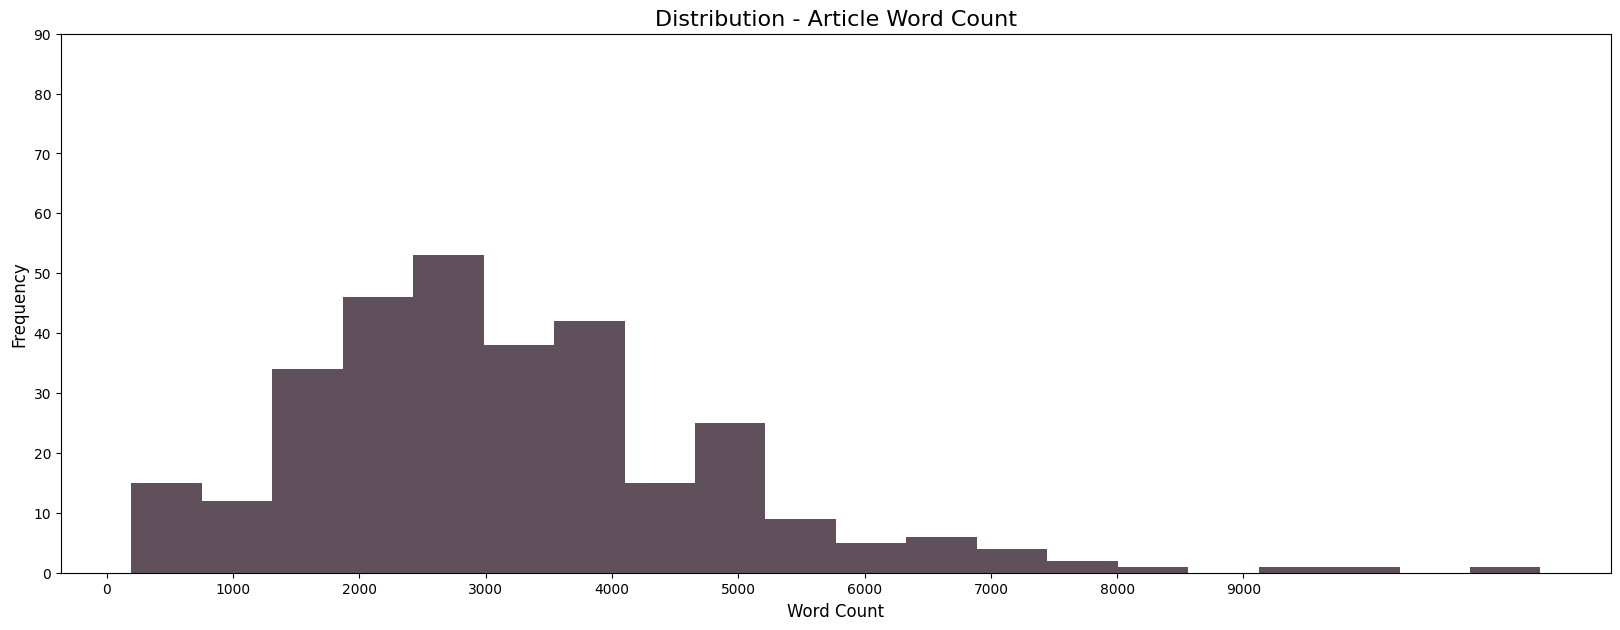

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Plot a hist of the word counts
fig = plt.figure(figsize=(20,7))

plt.hist(
    df['word_count'],
    bins=20,
    color='#60505C'
)

plt.title('Distribution - Article Word Count', fontsize=16)
plt.ylabel('Frequency', fontsize=12)
plt.xlabel('Word Count', fontsize=12)
plt.yticks(np.arange(0, 100, 10))
plt.xticks(np.arange(0, 10000, 1000))

file_name = 'hist'

plt.show()

In [39]:
from collections import Counter

# Get the top 20 most common words among all the articles
p_text = df['processed_text']

# Flatten the list of lists
p_text = [item for sublist in p_text for item in sublist]

# Top 20
top_20 = pd.DataFrame(
    Counter(p_text).most_common(20),
    columns=['word', 'frequency']
)

top_20

,word,frequency
0,patient,15245
1,brain,10524
2,consciousness,7128
3,study,6962
4,injury,5427
5,network,4915
6,state,4840
7,score,4369
8,connectivity,4069
9,functional,4050


C:\Users\noahj\AppData\Local\Temp\ipykernel_3188\2553095217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
C:\Users\noahj\AppData\Local\Temp\ipykernel_3188\2553095217.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(


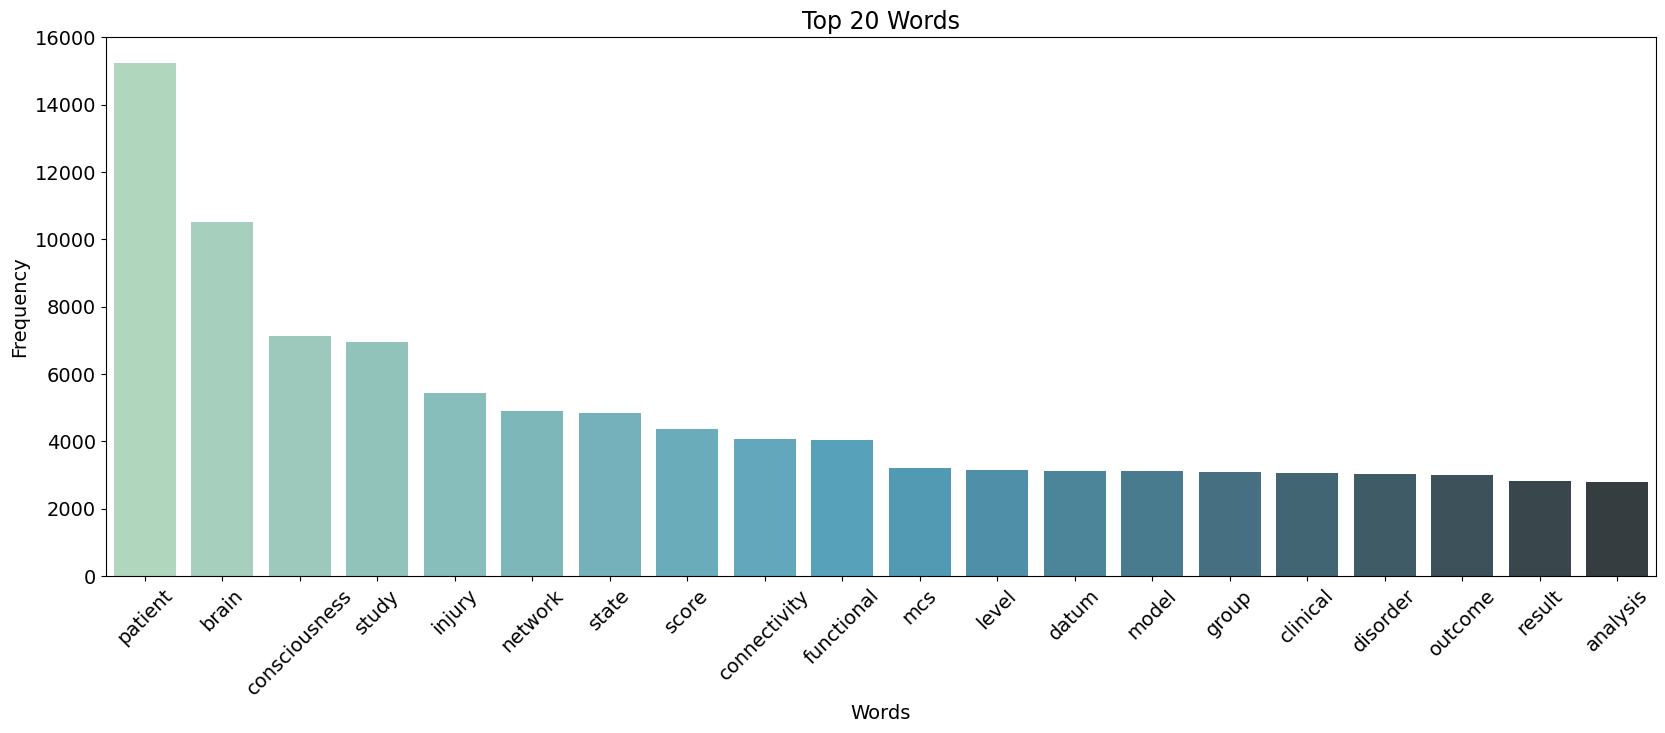

In [40]:
import seaborn as sns

# Plot a bar chart for the top 20 most frequently occurring words
fig = plt.figure(figsize=(20,7))

g = sns.barplot(
    x='word',
    y='frequency',
    data=top_20,
    palette='GnBu_d'
)

g.set_xticklabels(
    g.get_xticklabels(),
    rotation=45,
    fontsize=14
)

plt.yticks(fontsize=14)
plt.xlabel('Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Top 20 Words', fontsize=17)

plt.show()

In [41]:
# Get the number of unique words after processing
num_unique_words = len(set(p_text))
num_unique_words

119214

In [42]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from operator import itemgetter

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# create a dataframe with the text data
df['string_text'] = df["processed_text"].apply(lambda x: ' '.join(x))


df.head()

# create the TfidfVectorizer object
vectorizer = TfidfVectorizer()

# fit the vectorizer to the data and transform the data
tfidf_scores = vectorizer.fit_transform(df['string_text'])

# get the feature names
feature_names = vectorizer.get_feature_names_out()

# create a dataframe with the tf-idf scores
tfidf_df = pd.DataFrame(tfidf_scores.toarray(), columns=feature_names)

In [44]:
# calculate the mean tf-idf value for each word across the corpus
mean_tfidf = tfidf_df.mean()

# sort the mean tf-idf values in descending order
mean_tfidf = mean_tfidf.sort_values(ascending=False)

# view the top 10 most important words
print(mean_tfidf.head(10))

patient          0.122064
brain            0.070098
consciousness    0.056265
study            0.049282
injury           0.044375
mcs              0.044227
score            0.044001
network          0.042281
connectivity     0.042145
state            0.037383
dtype: float64


In [45]:
dict_path = r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Dictionaries\aalbi2026.csv"
dictionary = []
dictionary = pd.read_csv(dict_path)["Replacement"].tolist()
dictionary

['precentral',
 'frontal_sup',
 'frontal_mid',
 'frontal_inf_oper',
 'frontal_inf_tri',
 'frontal_inf_orb',
 'rolandic_oper',
 'supp_motor_area',
 'olfactory',
 'frontal_sup_medial',
 'frontal_med_orb',
 'rectus',
 'ofcmed',
 'ofcant',
 'ofcpost',
 'ofclat',
 'insula',
 'cingulate_ant',
 'cingulate_mid',
 'cingulate_post',
 'hippocampus',
 'parahippocampal',
 'amygdala',
 'calcarine',
 'cuneus',
 'lingual',
 'occipital_sup',
 'occipital_mid',
 'occipital_inf',
 'fusiform',
 'postcentral',
 'parietal_sup',
 'parietal_inf',
 'supramarginal',
 'angular',
 'precuneus',
 'paracentral_lobule',
 'caudate',
 'putamen',
 'pallidum',
 'heschl',
 'temporal_sup',
 'temporal_pole_sup',
 'temporal_mid',
 'temporal_pole_mid',
 'temporal_inf',
 'cerebellum_crus',
 'cerebellum_aal',
 'vermis',
 'thalamus',
 'thal_av',
 'thal_lp',
 'thal_va',
 'thal_vl',
 'thal_vpl',
 'thal_il',
 'thal_re',
 'thal_mdm',
 'thal_mdl',
 'thal_lgn',
 'thal_mgn',
 'thal_pua',
 'thal_pum',
 'thal_pul',
 'thal_pui',
 'thal_nuc

In [46]:
# create a list
my_list = dictionary

# create a set of items to remove from the list
remove_set = set([w for w in dictionary if w not in tfidf_df.columns])

# convert the list to a set and use the difference() method to remove the items
my_list = list(set(my_list).difference(remove_set))

# view the resulting list
print(my_list)

['insula', 'cingulate_mid', 'thalamus', 'parahippocampal', 'temporal_inf', 'ofcmed', 'putamen', 'heschl', 'cingulate_ant', 'supp_motor_area', 'ofcpost', 'rectus', 'temporal_sup', 'paracentral_lobule', 'temporal_pole_sup', 'frontal_inf_tri', 'hippocampus', 'supramarginal', 'amygdala', 'calcarine', 'postcentral', 'cuneus', 'parietal_sup', 'occipital_sup', 'thal_vpl', 'frontal_mid', 'ofclat', 'vermis', 'cerebellum_aal', 'olfactory', 'precentral', 'parietal_inf', 'lingual', 'pallidum', 'temporal_mid', 'occipital_mid', 'frontal_sup', 'occipital_inf', 'frontal_inf_oper', 'rolandic_oper', 'precuneus', 'fusiform', 'cingulate_post', 'caudate']


In [47]:
# create a list of the words to find the mean tf-idf values for
words = my_list

# calculate the mean tf-idf value for each word in the list
mean2_tfidf = tfidf_df[words].mean()

# sort the mean tf-idf values in descending order
mean2_tfidf = mean2_tfidf.sort_values(ascending=False)

# view the top 10 most important words
print(mean2_tfidf.head(10))

thalamus          0.008556
olfactory         0.004781
precuneus         0.004590
insula            0.003852
cerebellum_aal    0.002966
amygdala          0.002658
caudate           0.002501
hippocampus       0.002361
cingulate_post    0.002340
cingulate_ant     0.001942
dtype: float64


## 3.4 - Full Texts Non-NMF Corpus

In [48]:
import functions

In [49]:
functions.outputs.make_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\FullTexts_NON_TM", "txt")

In [ ]:
#csv called corpus.csv saved to current working directory


In [50]:
import pandas as pd
import csv

df=pd.read_csv('corpus.csv', encoding = 'unicode_escape', encoding_errors = 'ignore', engine ='c')
df.head()

,name,text
0,10663290.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
1,10663466.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
2,10663916.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
3,10672428.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
4,10674845.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...


In [51]:
df['processed_text'] = df['text'].apply(functions.processing.preprocess)
df.head()

,name,text,processed_text
0,10663290.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[introductioncongenital, acth, deficiency, rar..."
1,10663466.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[introductioncryptococcus, neoformans, bud, no..."
2,10663916.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,[]
3,10672428.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[qxdreceive, june, abstract, objective, studyw..."
4,10674845.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[case, report, dright, ventricular, cardiomyop..."


In [52]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x))
#add in a line to remove 0 wc texts
df = df[~(df.word_count == 0)]


df.head()

,name,text,processed_text,word_count
0,10663290.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[introductioncongenital, acth, deficiency, rar...",1002
1,10663466.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[introductioncryptococcus, neoformans, bud, no...",536
3,10672428.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[qxdreceive, june, abstract, objective, studyw...",1255
4,10674845.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[case, report, dright, ventricular, cardiomyop...",1105
5,10730735.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[pdfcan, anesth, purpose, proper, care, trauma...",1111


In [53]:
# Descriptive statistics for word count
df['word_count'].describe()
#95%CI Calculated: 

count     3298.000000
mean      2223.163432
std       1861.674988
min         13.000000
25%       1015.250000
50%       1949.000000
75%       3061.000000
max      64826.000000
Name: word_count, dtype: float64

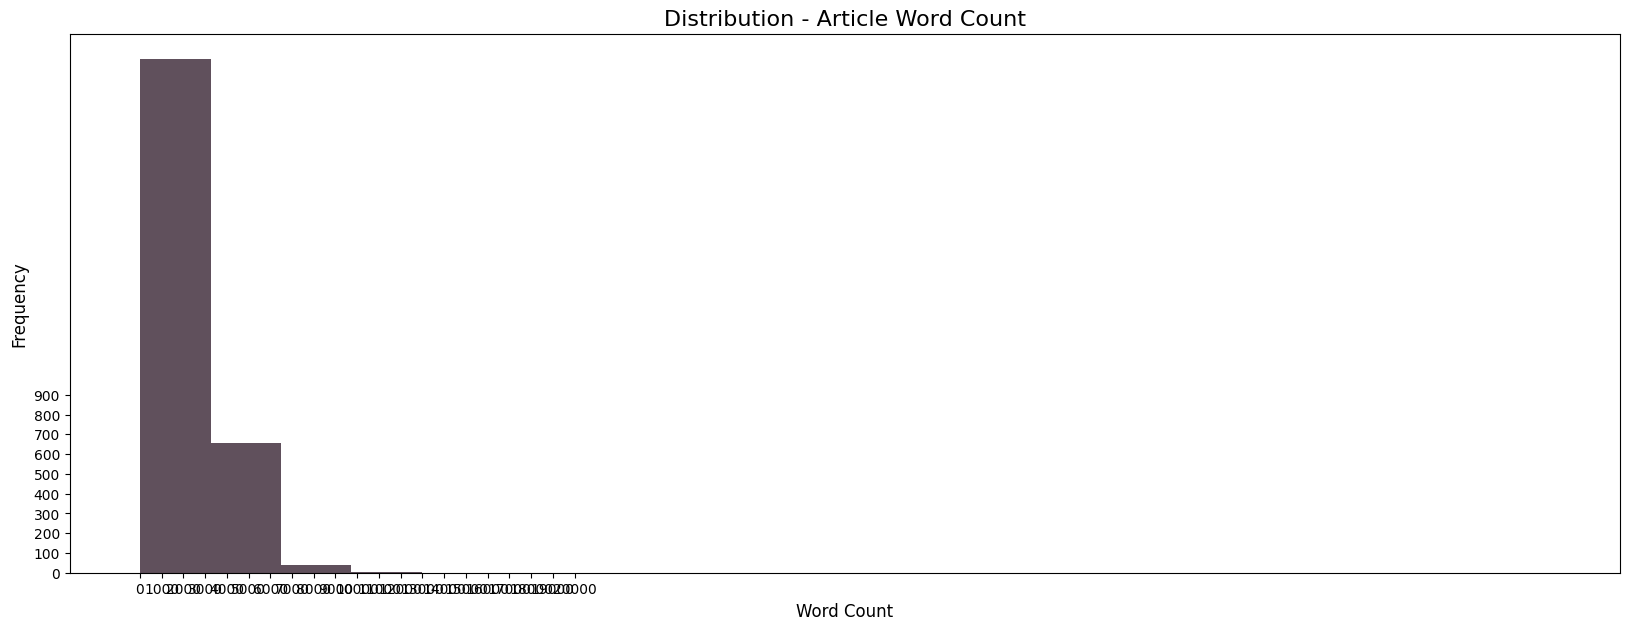

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Plot a hist of the word counts
fig = plt.figure(figsize=(20,7))

plt.hist(
    df['word_count'],
    bins=20,
    color='#60505C'
)

plt.title('Distribution - Article Word Count', fontsize=16)
plt.ylabel('Frequency', fontsize=12)
plt.xlabel('Word Count', fontsize=12)
plt.yticks(np.arange(0, 1000, 100))
plt.xticks(np.arange(0, 21000, 1000))

file_name = 'hist'

plt.show()

In [55]:
from collections import Counter

# Get the top 20 most common words among all the articles
p_text = df['processed_text']

# Flatten the list of lists
p_text = [item for sublist in p_text for item in sublist]

# Top 20
top_20 = pd.DataFrame(
    Counter(p_text).most_common(20),
    columns=['word', 'frequency']
)

top_20

,word,frequency
0,patient,105161
1,study,50340
2,brain,37531
3,group,27006
4,death,23231
5,clinical,22490
6,case,20146
7,consciousness,19755
8,time,19489
9,result,19359


C:\Users\noahj\AppData\Local\Temp\ipykernel_3188\2553095217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
C:\Users\noahj\AppData\Local\Temp\ipykernel_3188\2553095217.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(


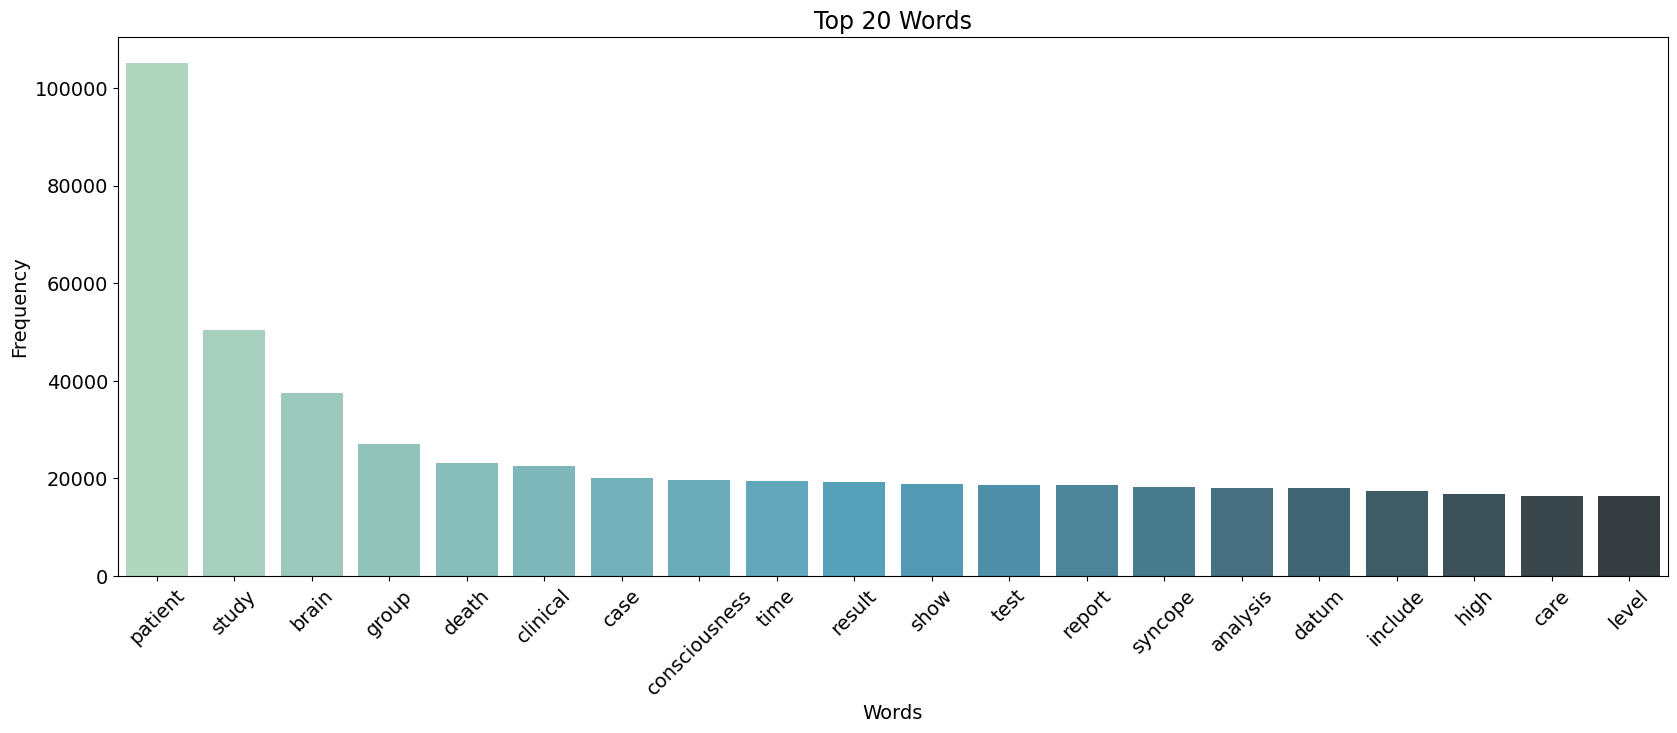

In [56]:
import seaborn as sns

# Plot a bar chart for the top 20 most frequently occurring words
fig = plt.figure(figsize=(20,7))

g = sns.barplot(
    x='word',
    y='frequency',
    data=top_20,
    palette='GnBu_d'
)

g.set_xticklabels(
    g.get_xticklabels(),
    rotation=45,
    fontsize=14
)

plt.yticks(fontsize=14)
plt.xlabel('Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Top 20 Words', fontsize=17)

plt.show()

In [57]:
# Get the number of unique words after processing
num_unique_words = len(set(p_text))
num_unique_words

644294

In [58]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from operator import itemgetter

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# create a dataframe with the text data
df['string_text'] = df["processed_text"].apply(lambda x: ' '.join(x))


df.head()

# create the TfidfVectorizer object
vectorizer = TfidfVectorizer()

# fit the vectorizer to the data and transform the data
tfidf_scores = vectorizer.fit_transform(df['string_text'])

# get the feature names
feature_names = vectorizer.get_feature_names_out()

# create a dataframe with the tf-idf scores
tfidf_df = pd.DataFrame(tfidf_scores.toarray(), columns=feature_names)

In [60]:
# calculate the mean tf-idf value for each word across the corpus
mean_tfidf = tfidf_df.mean()

# sort the mean tf-idf values in descending order
mean_tfidf = mean_tfidf.sort_values(ascending=False)

# view the top 10 most important words
print(mean_tfidf.head(10))

patient          0.071651
syncope          0.035925
brain            0.031779
study            0.031302
death            0.026716
group            0.019328
case             0.018365
consciousness    0.016660
clinical         0.016617
care             0.016450
dtype: float64


In [61]:
dict_path = r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Dictionaries\aalbi2026.csv"
dictionary = []
dictionary = pd.read_csv(dict_path)["Replacement"].tolist()
dictionary

['precentral',
 'frontal_sup',
 'frontal_mid',
 'frontal_inf_oper',
 'frontal_inf_tri',
 'frontal_inf_orb',
 'rolandic_oper',
 'supp_motor_area',
 'olfactory',
 'frontal_sup_medial',
 'frontal_med_orb',
 'rectus',
 'ofcmed',
 'ofcant',
 'ofcpost',
 'ofclat',
 'insula',
 'cingulate_ant',
 'cingulate_mid',
 'cingulate_post',
 'hippocampus',
 'parahippocampal',
 'amygdala',
 'calcarine',
 'cuneus',
 'lingual',
 'occipital_sup',
 'occipital_mid',
 'occipital_inf',
 'fusiform',
 'postcentral',
 'parietal_sup',
 'parietal_inf',
 'supramarginal',
 'angular',
 'precuneus',
 'paracentral_lobule',
 'caudate',
 'putamen',
 'pallidum',
 'heschl',
 'temporal_sup',
 'temporal_pole_sup',
 'temporal_mid',
 'temporal_pole_mid',
 'temporal_inf',
 'cerebellum_crus',
 'cerebellum_aal',
 'vermis',
 'thalamus',
 'thal_av',
 'thal_lp',
 'thal_va',
 'thal_vl',
 'thal_vpl',
 'thal_il',
 'thal_re',
 'thal_mdm',
 'thal_mdl',
 'thal_lgn',
 'thal_mgn',
 'thal_pua',
 'thal_pum',
 'thal_pul',
 'thal_pui',
 'thal_nuc

In [62]:
# create a list
my_list = dictionary

# create a set of items to remove from the list
remove_set = set([w for w in dictionary if w not in tfidf_df.columns])

# convert the list to a set and use the difference() method to remove the items
my_list = list(set(my_list).difference(remove_set))

# view the resulting list
print(my_list)

['insula', 'cingulate_mid', 'thalamus', 'parahippocampal', 'temporal_inf', 'ofcmed', 'putamen', 'heschl', 'cingulate_ant', 'supp_motor_area', 'ofcpost', 'rectus', 'temporal_sup', 'ofcant', 'paracentral_lobule', 'frontal_inf_tri', 'hippocampus', 'supramarginal', 'temporal_pole_sup', 'thal_il', 'amygdala', 'calcarine', 'postcentral', 'cuneus', 'parietal_sup', 'occipital_sup', 'frontal_mid', 'ofclat', 'vermis', 'cerebellum_aal', 'olfactory', 'precentral', 'parietal_inf', 'lingual', 'pallidum', 'temporal_mid', 'occipital_mid', 'frontal_sup', 'occipital_inf', 'frontal_inf_oper', 'rolandic_oper', 'precuneus', 'fusiform', 'cingulate_post', 'caudate']


In [63]:
# create a list of the words to find the mean tf-idf values for
words = my_list

# calculate the mean tf-idf value for each word in the list
mean2_tfidf = tfidf_df[words].mean()

# sort the mean tf-idf values in descending order
mean2_tfidf = mean2_tfidf.sort_values(ascending=False)

# view the top 10 most important words
print(mean2_tfidf.head(10))

thalamus           0.001852
cerebellum_aal     0.001344
hippocampus        0.000903
insula             0.000813
olfactory          0.000689
amygdala           0.000657
caudate            0.000579
precuneus          0.000543
cingulate_ant      0.000397
parahippocampal    0.000244
dtype: float64
